=== 📊 STEP 1: RAW DELAY MINUTES SPREAD ===
count    5000.000000
mean       14.553800
std         7.434794
min        -5.000000
25%        12.000000
50%        12.000000
75%        12.000000
max        26.000000
Name: Delay_Minutes, dtype: float64

=== ✈️ STEP 2: OPERATIONAL FREQUENCY MATRIX ===
Delay_Status  Minor Delay  On-Time/Early   All
Airline_Name                                  
Air India            1231             69  1300
Akasa Air             448             30   478
Indigo               2179            106  2285
Vistara               895             42   937
All                  4753            247  5000



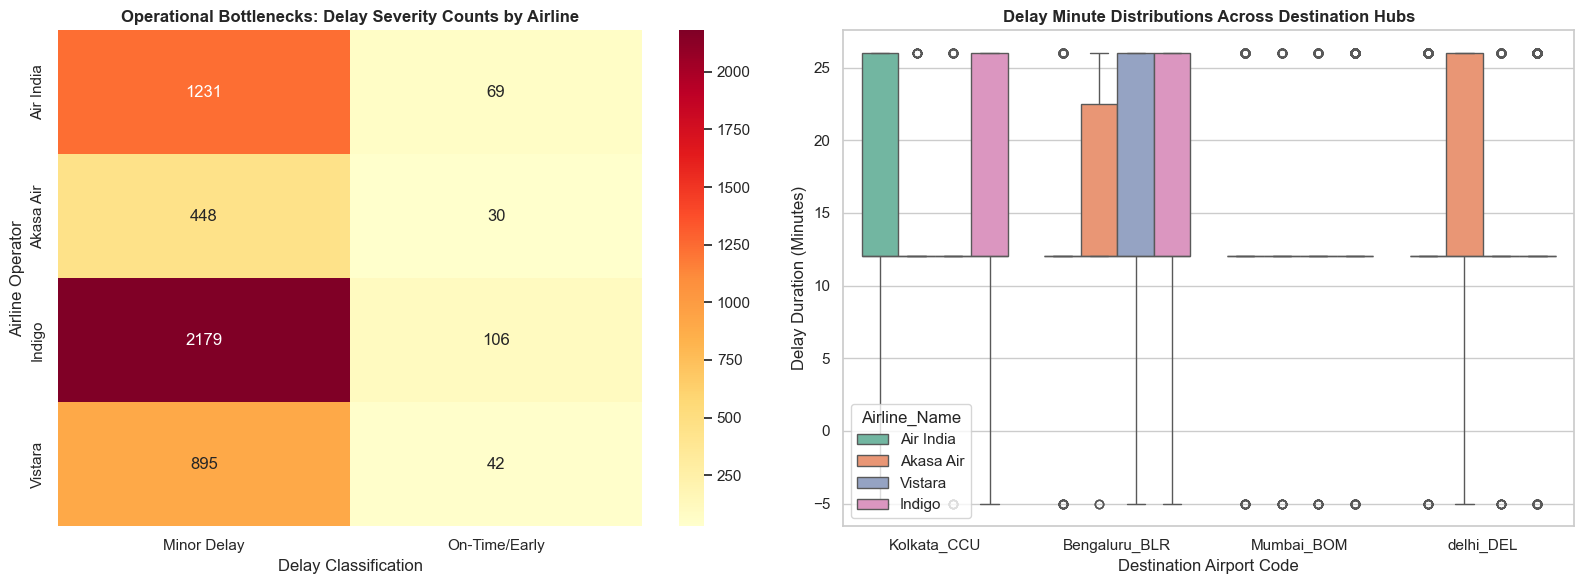

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# Load raw flight logs dataset
df= pd.read_csv('raw_flight_logs.csv')

print("=== 📊 STEP 1: RAW DELAY MINUTES SPREAD ===")
print(df['Delay_Minutes'].describe())
print("=========================================\n")

# ==================================================================
# 1. VECTORIZED CONDITION MAPPING (np.select)
# ==================================================================
# Problem: Raw numbers like '145 minutes' aren't friendly for executive dashboards.
# Action: Build a logical rule book to automatically bucket flights into distinct delay classes.

conditions = [
    df['Delay_Minutes'] <= 0, #Rule-1: Left on time or early
    (df['Delay_Minutes'] > 0 & (df['Delay_Minutes'] <= 15)), #Rule-2: Minor Buffer delay
    (df['Delay_Minutes'] > 15) & (df['Delay_Minutes'] <=60), #Rule-3:Moderate Delay
    df['Delay_Minutes'] > 60 #Rule-4: Major Delay
]

choices = ['On-Time/Early','Minor Delay','Moderate Dealy',"Severe Delay"]

# Apply the rules instantly using nump's fast matrix engine
df['Delay_Status'] = np.select(conditions,choices,default='Unknown')

# ===================================================================
# 2. MATRIX CROSS-TABULATION (pd.crosstab)
# ===================================================================
# Problem: Airport directors need to instantly spot which airlines suffer the most severe delays.
# Action: Generate a frequency count matrix comparing Airline names against Delay statuses.

delay_matrix = pd.crosstab(df['Airline_Name'], df['Delay_Status'], margins=True)

print("=== ✈️ STEP 2: OPERATIONAL FREQUENCY MATRIX ===")
print(delay_matrix)
print("=========================================\n")


# =====================================================================
# 3. GRAPHICAL PLOTTING (Heatmap and Count Distributions)
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart A: Heatmap visualization of the cross-tabulation table (excluding the 'All' totals)
sns.heatmap(
    pd.crosstab(df['Airline_Name'], df['Delay_Status']), 
    annot=True, 
    fmt='d', 
    cmap='YlOrRd', 
    cbar=True, 
    ax=axes[0]
)
axes[0].set_title('Operational Bottlenecks: Delay Severity Counts by Airline', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Delay Classification')
axes[0].set_ylabel('Airline Operator')

# Chart B: Distribution plot showing raw delay spreads across hubs
sns.boxplot(
    x='Destinations_Hub', 
    y='Delay_Minutes', 
    hue='Airline_Name', 
    data=df[df['Delay_Minutes'] <= 180], # Filter extreme values just to keep the plot legible
    palette='Set2', 
    ax=axes[1]
)
axes[1].set_title('Delay Minute Distributions Across Destination Hubs', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Destination Airport Code')
axes[1].set_ylabel('Delay Duration (Minutes)')

plt.tight_layout()
plt.show()